# 10강 연습문제

당신은 매일 아침 동네 빵집에서 식빵을 구입해 왔다.
이 식빵의 무게는 500g이라고 표시되어 있다. 하지만 당신은 자신이 구매하는 빵이 500g이 맞는
지 의구심이 들기 시작한다. 그래서 1개월간 식빵을 사운 뒤 매일 무게를 기록하였고 그 결과는
bread 데이터셋으로 저장하였다.
25일간 측정한 빵의 평균 무게는 480g이었다. 이 값을 가지고 식빵의 무게가 500g이 되지 않는
다며 베이커리를 찾아가 컴플레인을 해야 할까?

In [21]:
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
from pandas import DataFrame
import seaborn as sb
import numpy as np
from math import sqrt
# 단일표본 T-Test를 위한 라이브러리
from scipy.stats import t, normaltest, bartlett, levene, ttest_ind
from statannotations.Annotator import Annotator

In [4]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [5]:
origin = load_data('bread')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10/bread.xlsx
[desc] 매일 아침 동네 빵집에서 식빵을 구입해 무게를 기록한 데이터
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (25, 1)
열 개수: 1
행 개수: 25

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   무게      25 non-null     int64
dtypes: int64(1)
memory usage: 332.0 bytes
None


,무게
0,482
1,479
2,485
3,474
4,479


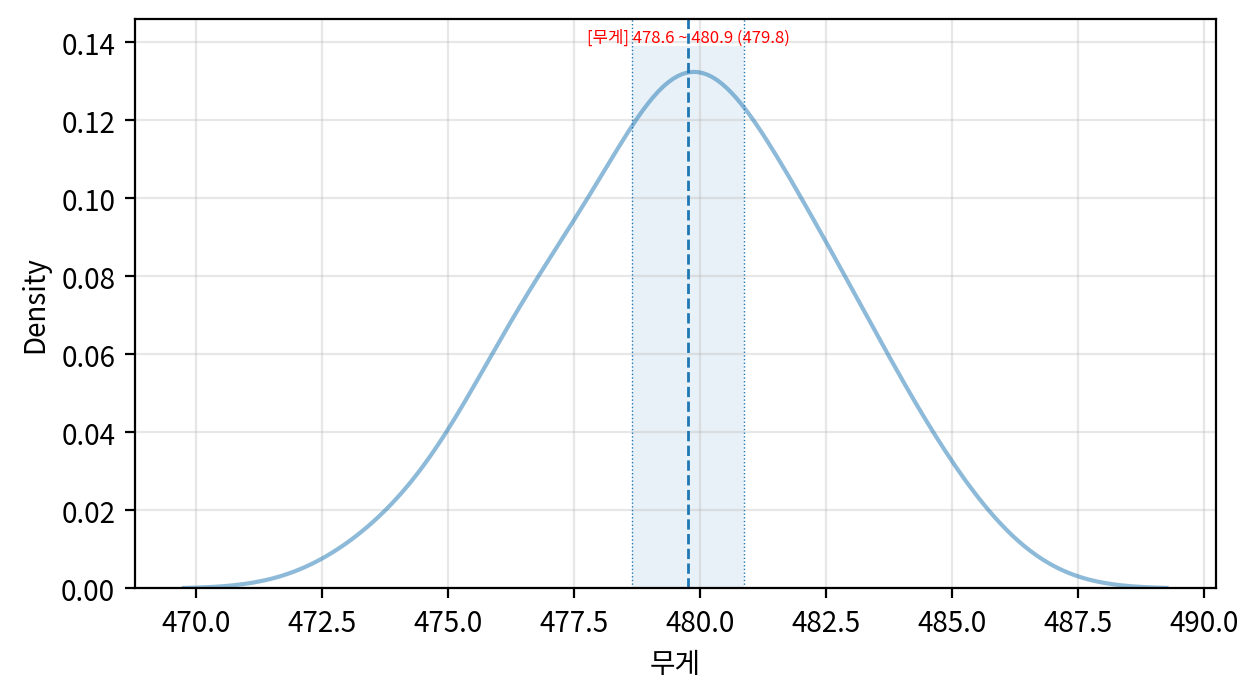

In [14]:
data = origin[['무게']] # 확인할 데이터
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
for c in data.columns:
    # KDE Plot 그리기
    sb.kdeplot(data=data, x=c, fill=False, alpha=0.5)
    # 신뢰구간
    max = data[c].max() # 최대값
    clevel = 0.95 # 신뢰수준
    dof = len(data[c]) - 1 # 자유도
    sp_mean = data[c].mean() # 표본평균
    sp_std = data[c].std(ddof=1) # 표본표준편차
    sp_std_error = sp_std / sqrt(len(data[c])) # 표본표준오차
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
    scale=sp_std_error)
    ax.axvline(cmin, linestyle=':', linewidth=0.5)
    ax.axvline(cmax, linestyle=':', linewidth=0.5)
    # 평균 표시
    ymin, ymax = ax.get_ylim()
    ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax.axvline(sp_mean, linestyle='--', linewidth=1)
    # 텍스트 그리기
    ax.text(x=(cmax-cmin)/2+cmin,
    y=ymax,
    s="[%s] %0.1f ~ %0.1f (%0.1f)" % (c, cmin, cmax,
    sp_mean),
    horizontalalignment="center",
    verticalalignment="bottom",
    fontdict={"size": 6, "color": "red"})

# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3) # 배경 격자 표시/숨김
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

In [22]:
data = origin[['무게']] # 검사하려는 데이터 추출

equal_var_fields = []
normal_dist = True
report = []

for c in data.columns:
    s, p = normaltest(data[c])
    normalize = p > 0.05
    report.append({
    "field": c,
    "statistic": s,
    "p-value": p,
    "result": normalize
 })
    normal_dist = normal_dist and normalize

# 변수가 두 개 이상인 경우 등분산성 확인
if len(data.columns) > 1:
    if normal_dist:
        n = "Bartlett"
        # 정규성을 충족할 경우의 검정방법
        s, p = bartlett(*data.values.T) # 모든 컬럼의 데이터를 한번에 전달
    else:
        n = "Levene" # 정규성을 충족하지 않을 경우의 검정방법
        s, p = levene(*data.values.T, center='median') # 모든 컬럼의 데이터를 한번에 전달
    report.append({
        "field": n,
        "statistic": s,
        "p-value": p,
        "result": p > 0.05
 })
    
report_df = DataFrame(report).set_index('field')
report_df

,statistic,p-value,result
field,,,
무게,0.083295,0.959208,True


In [18]:
s, p = ttest_1samp(origin['무게'], 500)
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(s, p, "대립" if p <= 0.05 else "귀무")

'statistic: -37.524, p-value: 0.000, 대립가설 채택'

In [12]:
s, p = ttest_1samp(origin['무게'], 500, alternative='less')
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(s, p, "대립" if p <= 0.05 else "귀무")

'statistic: -37.524, p-value: 0.000, 대립가설 채택'

In [20]:
s, p = ttest_1samp(origin['무게'], 500, alternative='greater')
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(s, p, "대립" if p <= 0.05 else "귀무")

'statistic: -37.524, p-value: 1.000, 귀무가설 채택'

해당 빵집의 신뢰구간은 478.6~480.9로써 빵의 평균 무게가 500이하가 확인이 된다
또한 T검정에 대한 해당 빵집의 무게 유의확률값은 0.000으로 통상적인 유의수준 0.05보다 작으므로 모집단의 평균인 500이라고 할 수 없다.(대립가설) 

In [1]:
from hossam import load_data
from pandas import melt, DataFrame
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from math import sqrt
from scipy.stats import t, normaltest, bartlett, levene, ttest_ind
from statannotations.Annotator import Annotator

In [2]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [4]:
origin = load_data('material')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/material.xlsx
[desc] 어떤 화학 약품에 사용되는 서로 다른 상표의 주성분 A 함량표 (출처: 방송통신대학교 통계학개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (11, 2)
열 개수: 2
행 개수: 11

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   상표1     11 non-null     float64
 1   상표2     11 non-null     float64
dtypes: float64(2)
memory usage: 308.0 bytes
None


,상표1,상표2
0,80.4,81.8
1,78.2,82.7
2,80.1,80.7
3,77.1,84.0
4,79.6,79.0


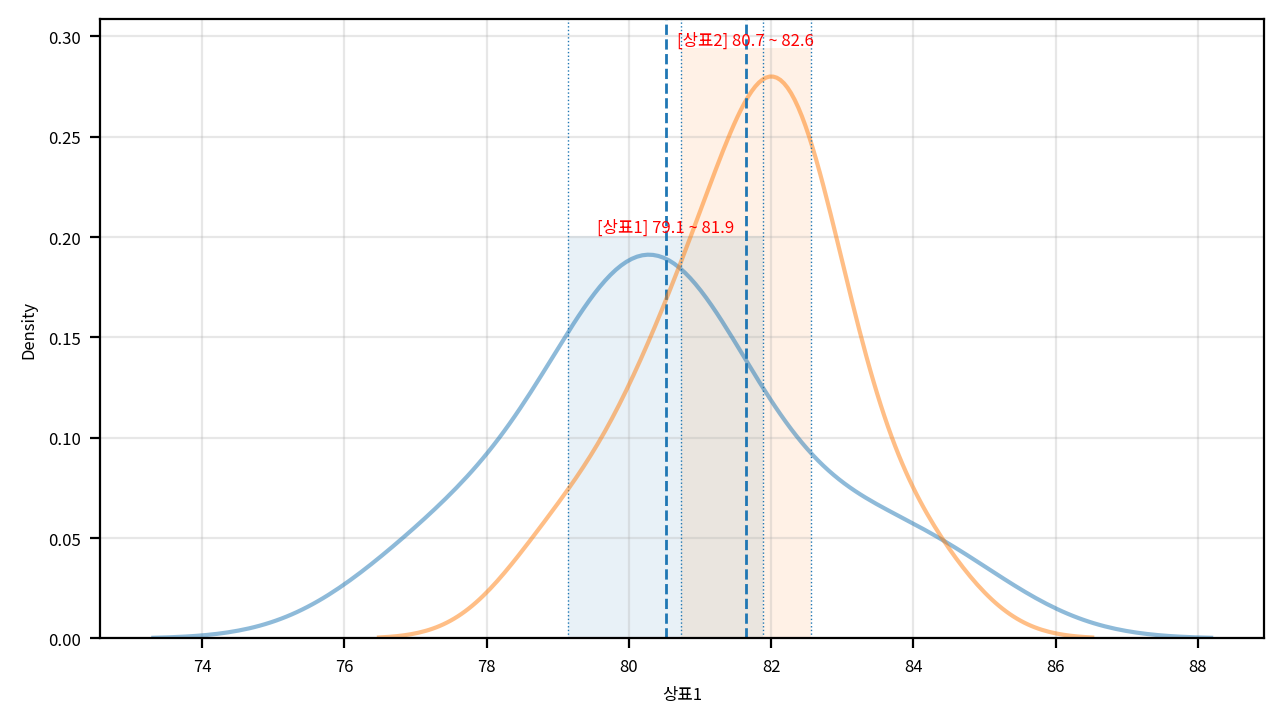

In [5]:
# 확인할 데이터
data = origin[['상표1', '상표2']]

# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1         # 그래프 행 수
cols = 1         # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

for c in data.columns:
    # KDE Plot 그리기
    sb.kdeplot(data=data, x=c, fill=False, alpha=0.5)

    # 신뢰구간 계산
    max_val = data[c].max()          # 최대값 (필요 시 사용)
    clevel = 0.95                    # 신뢰수준
    dof = len(data[c]) - 1           # 자유도
    sp_mean = data[c].mean()         # 표본평균
    sp_std = data[c].std(ddof=1)     # 표본표준편차
    sp_std_error = sp_std / sqrt(len(data[c]))  # 표본표준오차

    cmin, cmax = t.interval(
        clevel,
        dof,
        loc=sp_mean,
        scale=sp_std_error
    )

    # 신뢰구간 경계선
    ax.axvline(cmin, linestyle=':', linewidth=0.5)
    ax.axvline(cmax, linestyle=':', linewidth=0.5)

    # 평균 및 신뢰구간 영역 표시
    ymin, ymax = ax.get_ylim()
    ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax.axvline(sp_mean, linestyle='--', linewidth=1)

    # 텍스트 표시
    ax.text(
        x=(cmax - cmin) / 2 + cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (c, cmin, cmax),
        horizontalalignment="center",
        verticalalignment="bottom",
        fontdict={"size": 6, "color": "red"}
    )

# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3)  # 배경 격자 표시

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


In [6]:
# 검사하려는 데이터 추출
data = origin[['상표1', '상표2']]

equal_var_fields = []
normal_dist = True
report = []

# 각 변수별 정규성 검정
for c in data.columns:
    s, p = normaltest(data[c])
    normalize = p > 0.05

    report.append({
        "field": c,
        "statistic": s,
        "p-value": p,
        "result": normalize
    })

    normal_dist = normal_dist and normalize

# 변수가 두 개 이상인 경우 등분산성 확인
if len(data.columns) > 1:
    if normal_dist:
        n = "Bartlett"  # 정규성을 충족할 경우의 검정 방법
        # 모든 컬럼의 데이터를 한 번에 전달
        s, p = bartlett(*data.values.T)
    else:
        n = "Levene"    # 정규성을 충족하지 않을 경우의 검정 방법
        # 모든 컬럼의 데이터를 한 번에 전달
        s, p = levene(*data.values.T, center='median')

    report.append({
        "field": n,
        "statistic": s,
        "p-value": p,
        "result": p > 0.05
    })

# 결과를 DataFrame으로 정리
report_df = DataFrame(report).set_index('field')
report_df


,statistic,p-value,result
field,,,
상표1,0.638272,0.726777,True
상표2,0.774961,0.678765,True
Bartlett,1.555316,0.212352,True


In [7]:
# 검정할 데이터 필드명
fields = ['상표1', '상표2']

# 로그 적용 여부
use_log = False

# 검정할 데이터
df = origin[fields]

# 검사할 알고리즘
alternative = ["two-sided", "less", "greater"]

# 결과를 저장할 빈 리스트
result = []

# 가설식 템플릿
fmt = "μ({f0}) {0} μ({f1})"

# 등분산성 충족 여부
equal_var = True

for a in alternative:
    if use_log:
        input1 = np.log(df[fields[0]])
        input2 = np.log(df[fields[1]])
    else:
        input1 = df[fields[0]]
        input2 = df[fields[1]]
    s, p = ttest_ind(input1, input2, alternative=a,equal_var=equal_var)

    itp = None

    if a == "two-sided":
        itp = fmt.format("/=" if p > 0.05 else "/=", f0=fields[0],f1=fields[1])
    elif a == "less":
        itp = fmt.format("/=" if p > 0.05 else "<", f0=fields[0],f1=fields[1])
    else:
        itp = fmt.format("/=" if p > 0.05 else ">", f0=fields[0],f1=fields[1])

    result.append({
        "alternative": a, # 검정의 의미
        "statistic": s, # 통계량
        "p-value": p, # 유의수준
        "H0": p > 0.05, # 귀무가설 채택 여부
        "H1": p <= 0.05, # 대립가설 채택 여부
        "interpretation": itp # 해석 결과
    })
    
    
    # 두 집단의 평균이 같다고 판정되면 이후 less, greater는 무의미하므로 중단
    if a == "two-sided" and p > 0.05:
        break
rdf = DataFrame(result)
rdf.set_index("alternative", inplace=True)
rdf

,statistic,p-value,H0,H1,interpretation
alternative,,,,,
two-sided,-1.528327,0.142093,True,False,μ(상표1) /= μ(상표2)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상표1 vs. 상표2: t-test independent samples, P_val:1.421e-01 t=-1.528e+00


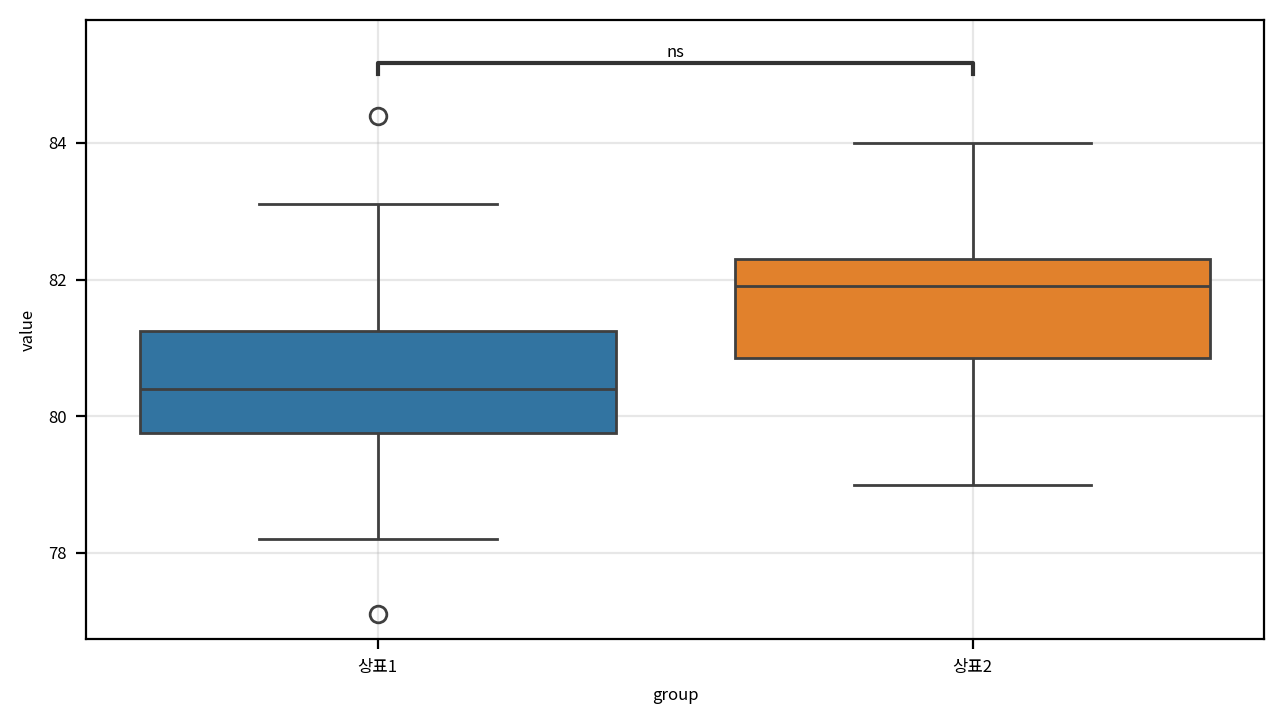

In [10]:
# 검정할 데이터 필드명
fields = ['상표1', '상표2']
# 검정 방법
# `t-test_ind`, `t-test_paired`, `t-test_welch`, `Mann-Whitney`,
# `Mann-Whitney-gt`, `Mann-Whitney-ls`, `Levene`, `Wilcoxon`,`Kruskal`
test_method = 't-test_ind'
# 데이터 재배치
df = melt(origin[fields], value_vars=fields, var_name='group',
value_name='value')

# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) BoxPlot 그리기
sb.boxplot(data=df, x='group', y='value', hue='group')
annotator = Annotator(ax, data=df, x='group', y='value',pairs=[fields])
annotator.configure(test=test_method)
annotator.apply_and_annotate()
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3) # 배경 격자 표시
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료